In [2]:
import numpy as np
import matplotlib.pyplot as plt
import neutrino_mc_log as nmc
import definition as df
import multiprocessing as mp
from functools import partial
import platform

print(platform.architecture())

print(nmc.normalized_rate_x(30, 10, 0.01))


('64bit', 'WindowsPE')
0.0016667644148363806


In [ ]:
E_nu_0 = 30
x_max = 60 # must be divisible by 3 for the plotting to work correctly
x_0_list = np.logspace(-2, 1, x_max) 
m_phi_space = np.concatenate((np.logspace(0, 2, 50), np.logspace(2, 2.5, 200), np.logspace(2.5, 4, 50)))  # More points around m_phi ~ T_nu

worker_func = partial(nmc.compute_row, E_nu_0=E_nu_0, m_phi=m_phi_space)

ctx = mp.get_context('spawn')  # Use 'spawn' to avoid issues on some platforms
nproc = mp.cpu_count() - 1  # Leave one CPU free

with ctx.Pool(processes=nproc) as pool:
    y_values = pool.map(worker_func, x_0_list)

y_values_array = np.array(y_values)
np.save(r"F:/Neutrino_SI/Data/normalized_rate.npy", y_values_array)

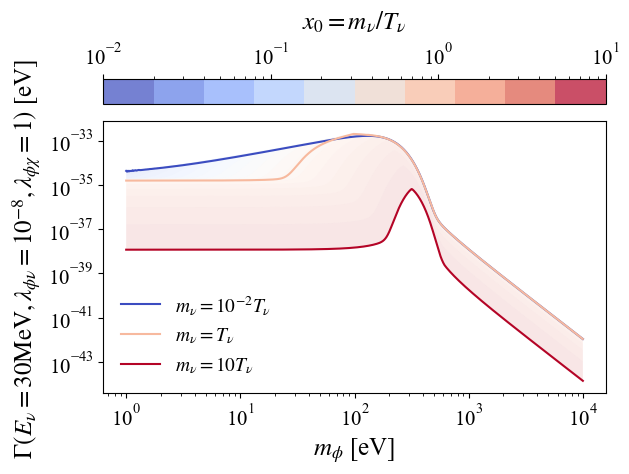

Error in callback <function _draw_all_if_interactive at 0x000001ADF98131A0> (for post_execute), with arguments args (),kwargs {}:


AttributeError: 'Colorbar' object has no attribute '_boundaries'

In [32]:
from matplotlib.colors import LogNorm, LinearSegmentedColormap
from matplotlib.cm import ScalarMappable
from scipy.signal import savgol_filter  # Import the smoothing filter
from scipy.interpolate import InterpolatedUnivariateSpline as IUS

# print(plt.colormaps())

my_colors = ["purple", "hotpink", "orange", 'white']
# cmap = LinearSegmentedColormap.from_list("my_custom_map", my_colors, N=256)

color = 'coolwarm'  # Choose a built-in colormap that goes from purple to red

E_nu_0 = 30
x_max = 60
x_0_list = np.logspace(-2, 1, x_max) 
m_phi_space = np.concatenate((np.logspace(0, 2, 250), np.logspace(2, 2.5, 1000), np.logspace(2.5, 4, 250)))  # More points around m_phi ~ T_nu

cmap = plt.get_cmap(color)  # Use a built-in colormap that goes from purple to red
norm = LogNorm(vmin=x_0_list.min(), vmax=x_0_list.max())

y_values = np.load(r"./Bin/smellycat260608/data/normalized_rate.npy")

lambda_phi = 1e-8
for i in range(len(x_0_list)):
    y_values[i] = y_values[i]*df.T_nu**3*lambda_phi**2/m_phi_space**2/(4*np.pi**2)

fig, ax = plt.subplots()
# y_values_smoothed = savgol_filter(y_values, window_length=4, polyorder=1, axis=1)  # Smooth each row

ratio = int(3)
for i, x_0 in enumerate(x_0_list):
    if i == 0 or (i+1) % ratio == 0:  # Plot every 'ratio' lines to reduce clutter
        if i < len(x_0_list) - 1:
            ax.fill_between(m_phi_space, y_values[i], y_values[i+ratio], color=cmap(norm(x_0_list[i])), alpha=0.12, edgecolor='none')

# or
# for i, x_0 in enumerate(x_0_list):
#     if i < len(x_0_list) - 1:
#         ax.fill_between(m_phi_space, y_values[i], y_values[i+1], color=cmap(norm(x_0_list[i])), alpha=0.12, edgecolor='none')

    # ax.fill_between(m_phi_space, y_values[57], y_values[59], color=cmap(norm(x_0_list[57])), alpha=0.01, edgecolor='none')     
        # ax.fill_between(m_phi_space, y_values[i], y_values[i+1], color=cmap(norm(x_0_list[i])),  alpha=0.15,  edgecolor='none')     # Ensures no edge color is drawn)

    # if i == len(x_0_list)-1:
    #     ax.fill_between(m_phi_space, y_values[i], y_values[i-4], color=cmap(norm(x_0_list[i])), alpha=0.1)


ax.plot(m_phi_space, y_values[0], color=cmap(norm(x_0_list[0])), linestyle='-', label=r'$m_\nu = 10^{-2}T_\nu$')
# ax.plot(m_phi_space, y_values[int(1/3 * x_max -1)], color=cmap(norm(x_0_list[int(1/3 * x_max -1)])), linestyle='-', label=r'$m_\nu = 10^{-1}T_\nu$')
ax.plot(m_phi_space, y_values[int(2/3 * x_max -1)], color=cmap(norm(x_0_list[int(2/3 * x_max -1)])), linestyle='-', label=r'$m_\nu = T_\nu$')
ax.plot(m_phi_space, y_values[int(x_max -1)], color=cmap(norm(x_0_list[int( x_max -1)])), linestyle='-', label=r'$m_\nu = 10T_\nu$')

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix' # STIX fonts look very similar to Times New Roman

label_fontsize = 18
tick_fontsize = 15

ax.set_xlabel(r"$m_\phi$ [eV]", fontsize=label_fontsize)
ax.set_ylabel(r"$\Gamma(E_\nu = 30 \mathrm{MeV}, \lambda_{\phi\nu} = 10^{-8}, \lambda_{\phi\chi} =1)$ [eV] ", fontsize=label_fontsize)
ax.set_xscale("log")
ax.set_yscale("log")

# ax.set_ylim(1e-4, 1e1)
# ax.set_xlim(m_phi_space.min(), m_phi_space.max())

ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
ax.legend(fontsize=14, loc='lower left', frameon=False)

cmap = plt.get_cmap(color, 10) 
sm = ScalarMappable(cmap = cmap, norm = norm)
sm.set_array([]) 

cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', location='top',extend='neither',pad=0.05, alpha = 0.7)
cbar.set_label(r"$x_0 = m_\nu / T_\nu$", fontsize=label_fontsize, labelpad=10)
cbar.ax.tick_params(labelsize=tick_fontsize)


plt.tight_layout()
plt.savefig("F:/Neutrino_SI/Plots/normalized_rate.pdf")  
fig


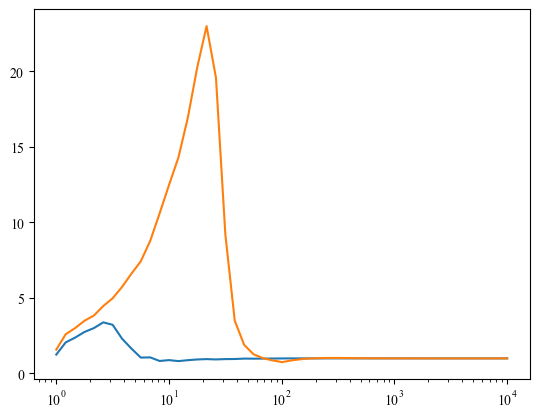

In [13]:
E_nu_0 = 30
x_0_list = [0.01, 0.1, 1]
m_phi_space = np.concatenate((np.logspace(0, 2, 25), np.logspace(2, 2.5, 150), np.logspace(2.5, 4, 25)))  # More points around m_phi ~ T_nu

y_values = np.zeros((len(x_0_list), len(m_phi_space)))
for i, x_0 in enumerate(x_0_list):
    y_values[i,:] = nmc.compute_row_x(x_0, E_nu_0, m_phi_space)
    
fig, ax = plt.subplots()
for i in range(len(x_0_list)-1):
    ax.plot(m_phi_space, y_values[0]/y_values[i+1], linestyle='-')

ax.set_xscale("log")
# ax.set_yscale("log")
fig

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

x_0_space = np.logspace(-2, 2, 200) 
m_phi_space = np.concatenate((np.logspace(0, 2, 25), np.logspace(2, 2.5, 150), np.logspace(2.5, 4, 25)))  # More points around m_phi ~ T_nu

M_phi, X_0 = np.meshgrid(m_phi_space, x_0_space)
nr_values = np.zeros_like(M_phi)

for i, x_0 in enumerate(x_0_space):
    nr_values[i,:] = nmc.normalized_rate_x(30, m_phi_space, x_0)

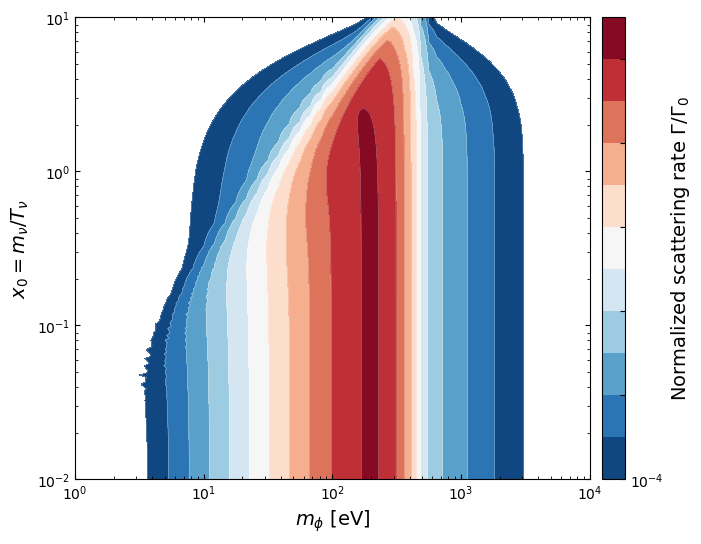

In [47]:
from scipy.signal import savgol_filter  # Import the smoothing filter

nr_values_smoothed = np.zeros_like(M_phi)
for i, x_0 in enumerate(x_0_space):
    nr_values_smoothed[i,:] = savgol_filter(nr_values[i,:], window_length=4, polyorder=2)

fig, ax = plt.subplots(figsize=(8, 6))
levels = np.logspace(-4, 1, 12)

# 2. Draw the filled color blocks
cs = ax.contourf(
    M_phi, X_0, nr_values, 
    levels=levels, 
    norm=LogNorm(vmin=1e-4, vmax=1e1), 
    cmap='RdBu_r' # Or 'inferno'/'magma' to match your reference image closer
)

ax.contour(
    M_phi, X_0, nr_values, 
    levels=levels, 
    colors='white',     # Color of the dividing lines
    linewidths=0.3,     # Keep them thin so they don't overpower the data
    alpha=0.6           # Slight transparency so they blend well
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$m_\phi$ [eV]", fontsize=14)
ax.set_ylabel(r"$x_0 = m_\nu / T_\nu$", fontsize=14)
ax.set_xlim(1e0,1e4)
ax.set_ylim(1e-2, 1e1)

# Attach the colorbar to the filled contour object ('cs')
cbar = fig.colorbar(cs, ax=ax, pad=0.02)
cbar.set_label(r"Normalized scattering rate $\Gamma/\Gamma_0$", fontsize=14)
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
ax.tick_params(top=True, right=True, which='both')

plt.show()